<a href="https://colab.research.google.com/github/arshadraza1205/Data-analysis/blob/main/Customer_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

# CSV file upload
df = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')

# view first 5 record of data
print("Shape of Dataset:", df.shape)
df.head()

Shape of Dataset: (250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [9]:
# 1. Check missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# 2. Fill missing values in 'Returns' with 0
df['Returns'] = df['Returns'].fillna(0)

# 3. Convert 'Purchase Date' to datetime format
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# 4. Drop redundant 'Customer Age' column if duplicate exists
if 'Customer Age' in df.columns and 'Age' in df.columns:
    df.drop(columns=['Customer Age'], inplace=True)

print("\nData Cleaning Complete! Remaining null values:\n", df.isnull().sum())

Missing values before cleaning:
 Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

Data Cleaning Complete! Remaining null values:
 Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64


In [10]:
# Reference date for recency calculation (day after the latest transaction)
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics per customer
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
}).rename(columns={
    'Purchase Date': 'Recency',
    'Customer ID': 'Frequency',
    'Total Purchase Amount': 'Monetary'
})

print("RFM Summary Statistics:")
rfm.describe()

RFM Summary Statistics:


,Recency,Frequency,Monetary
count,49673.000000,49673.000000,49673.000000
mean,261.424979,5.032915,13716.559962
std,246.024001,2.206427,6840.208557
min,1.000000,1.000000,110.000000
25%,78.000000,3.000000,8719.000000
50%,185.000000,5.000000,13026.000000
75%,369.000000,6.000000,17966.000000
max,1353.000000,17.000000,55339.000000


/tmp/ipykernel_2228/2801073201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, ax=axes[0], palette='viridis')


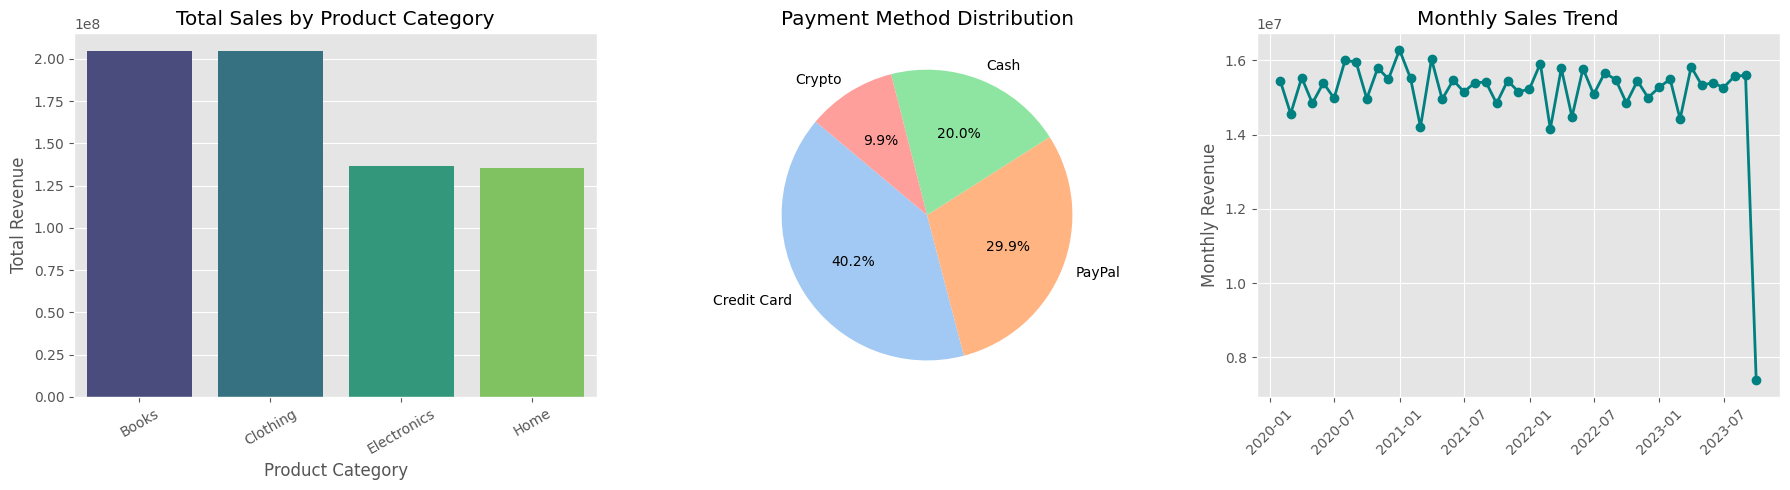

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Total Sales by Product Category
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, ax=axes[0], palette='viridis')
axes[0].set_title('Total Sales by Product Category')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Payment Method Breakdown
payment_counts = df['Payment Method'].value_counts()
axes[1].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title('Payment Method Distribution')

# Chart 3: Monthly Revenue Trend
monthly_sales = df.set_index('Purchase Date').resample('ME')['Total Purchase Amount'].sum()
axes[2].plot(monthly_sales.index, monthly_sales.values, marker='o', color='teal', linewidth=2)
axes[2].set_title('Monthly Sales Trend')
axes[2].set_ylabel('Monthly Revenue')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()